In [1]:
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/vicleme/port-of-santos-credit-fx/refs/heads/main/data/processed/painel_2015_2025.csv"
df = pd.read_csv(url)
df.head()

,ano,mes,cambio_venda,ativo_total,credito_emprestimos_titulos,credito_financiamentos,credito_outras_operacoes,credito_total,passivo_total,exportação_fob,importação_fob,exportação_kg,importação_kg
0,2015,1,2.6623,3.483431e+10,2.571444e+09,304829194.0,78318169.0,1.002071e+10,3.483431e+10,3.559136e+09,4.610173e+09,4.703620e+09,1.970297e+09
1,2015,2,2.8782,3.293911e+10,2.571864e+09,306515589.0,77453579.0,7.849779e+09,3.293911e+10,3.151947e+09,3.918598e+09,2.776368e+09,1.637549e+09
2,2015,3,3.2080,3.363779e+10,2.581877e+09,309676630.0,77760110.0,7.993315e+09,3.363779e+10,5.252621e+09,4.790111e+09,6.534975e+09,2.197364e+09
3,2015,4,2.9936,3.698674e+10,2.579874e+09,306669262.0,75892847.0,1.188595e+10,3.698674e+10,3.194954e+09,4.191985e+09,2.576431e+09,1.696601e+09
4,2015,5,3.1788,3.474094e+10,2.581429e+09,307947174.0,74945960.0,9.573599e+09,3.474094e+10,5.000342e+09,4.075543e+09,7.159526e+09,1.740346e+09


### Como ler os gráficos abaixo
Pra cada variável do painel, mostramos dois gráficos lado a lado que se complementam:

- **Histograma (esquerda):** conta em quantos dos meses observados o valor da variável caiu em cada faixa. Mostra o *formato* da distribuição — se os valores costumam ficar concentrados numa faixa só ou espalhados, se existe assimetria (uma cauda mais longa pra um lado), etc.
- **Boxplot horizontal (direita):** resume a mesma variável em poucos números — o menor valor típico (mín.), o valor abaixo do qual estão 25% dos meses (Q1), o valor do meio (mediana), o valor abaixo do qual estão 75% dos meses (Q3), o maior valor típico (máx.) e a média (losango vermelho). Os círculos fora dessa faixa são meses **atípicos** — bem mais altos ou mais baixos do que o normal do período.

Juntos, os dois respondem perguntas diferentes: o histograma mostra a *forma* da distribuição; o boxplot resume ela em poucos números e evidencia os meses fora do padrão. Quando existem meses atípicos, mostramos logo abaixo a linha completa do painel pra esses meses, já na mesma escala dos gráficos. Nessa tabela, cada célula é comparada com o **Q1 e o Q3 daquela variável ao longo de todo o período** (os mesmos números do boxplot dela): 🔵 **azul** = abaixo do Q1 (baixo pro padrão da variável), 🟠 **laranja** = acima do Q3 (alto pro padrão da variável), sem cor = dentro da faixa típica (entre Q1 e Q3).

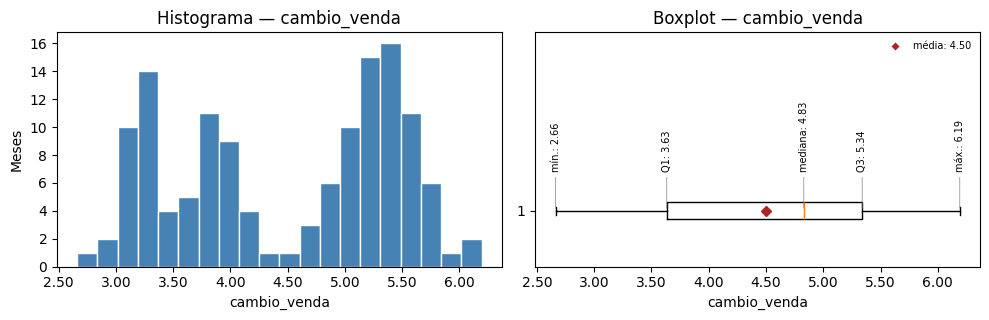

**cambio_venda** — Câmbio (PTAX de venda): quanto mais alto, mais caro está o dólar em reais — um real mais fraco, o que tende a encarecer importações e favorecer exportadores.

Ao longo dos 132 meses observados, o valor variou entre 2.66 (jan/2015) e 6.19 (dez/2024), com valor típico (mediana) de 4.83.

A distribuição é relativamente simétrica — média (4.50) e mediana (4.83) ficam próximas, sem uma cauda dominante de um lado só.

O boxplot não aponta nenhum mês fora do padrão típico (outliers) — o comportamento se manteve dentro de uma faixa relativamente previsível ao longo de todo o período.

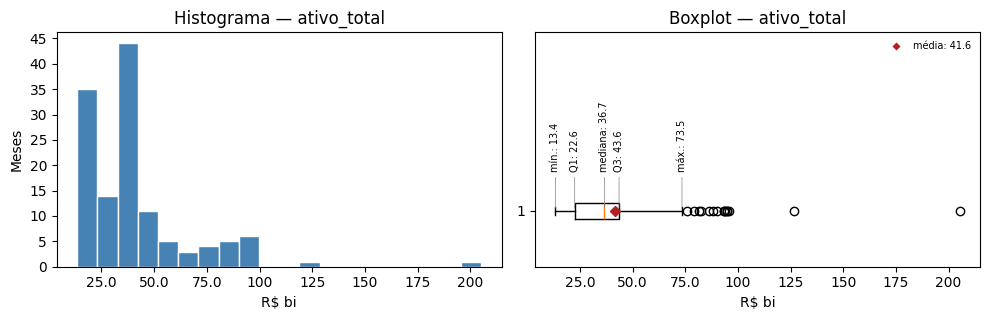

**ativo_total** — Ativo total dos bancos com agência em Santos: soma de tudo que esses bancos possuem (principalmente os empréstimos que concederam). Funciona como um termômetro do tamanho do sistema bancário na praça de Santos, mês a mês.

Ao longo dos 129 meses observados, o valor variou entre 13.4 (jul/2025) e 205 (mai/2016) R$ bi, com valor típico (mediana) de 36.7 R$ bi.

A distribuição é assimétrica à direita: a maioria dos meses tem valores mais baixos, mas alguns meses puxam bastante pra cima — por isso a média (41.6) fica acima da mediana (36.7).

O boxplot aponta 15 mês(es) fora do padrão típico da série (outliers), concentrados principalmente em 2016, 2017, 2018, 2019.

Nesses mesmos meses: **cambio_venda** esteve baixo (abaixo do Q1) em 8 de 15 meses; **credito_total** esteve alto (acima do Q3) em todos os 15 meses; **importação_kg** esteve baixo (abaixo do Q1) em 8 de 15 meses.

A tabela abaixo traz a linha completa do painel pra esses meses, com as células fora da faixa típica (Q1–Q3) de cada variável destacadas.

**O que dá pra perceber só olhando a tabela acima:** nos meses em que `ativo_total` foge do padrão, outras variáveis também aparecem fora do seu próprio padrão nesses mesmos meses — é esse cruzamento visual (cores e valores lado a lado) que chama atenção entre `ativo_total`/`credito_total` e o câmbio. Mas aparecer junto numa tabela de outliers não é a mesma coisa que confirmar a relação: o notebook `03_agencias_ativo_credito.ipynb` formaliza isso — calcula a correlação de verdade, olha a evolução ano a ano, e testa se o fechamento de agências bancárias físicas em Santos (mesma fonte, ESTBAN) ajuda a explicar o padrão. Os notebooks 02 e 03 são extensões pontuais deste 01, nascidas de perguntas que surgiram olhando pros outliers; do notebook 04 em diante a gente retoma a sequência do roteiro (temporal → NaNs → correlação → estacionariedade → decomposição) mais à risca.

,ano,mes,cambio_venda,ativo_total (R$ bi),credito_total (R$ bi),exportação_fob (US$ bi),importação_fob (US$ bi),exportação_kg (mi t),importação_kg (mi t)
14,2016,3,3.56,82.7,18.4,5.41,3.13,9.31,1.55
15,2016,4,3.45,126,21.6,4.43,2.89,6.90,1.63
16,2016,5,3.60,205,18.9,4.50,3.26,6.69,1.74
34,2017,11,3.26,88.1,20.5,4.51,4.20,5.66,2.25
36,2018,1,3.16,94.1,20.8,4.16,4.33,5.41,2.22
37,2018,2,3.24,75.9,17.7,4.59,3.74,5.72,1.82
38,2018,3,3.32,86.3,26.4,6.34,4.18,9.31,1.98
39,2018,4,3.48,79.3,20.9,4.82,4.31,6.17,2.15
40,2018,5,3.74,81.5,22.3,5.89,3.95,9.95,1.73
49,2019,2,3.74,90.0,25.4,4.66,3.81,6.63,1.94


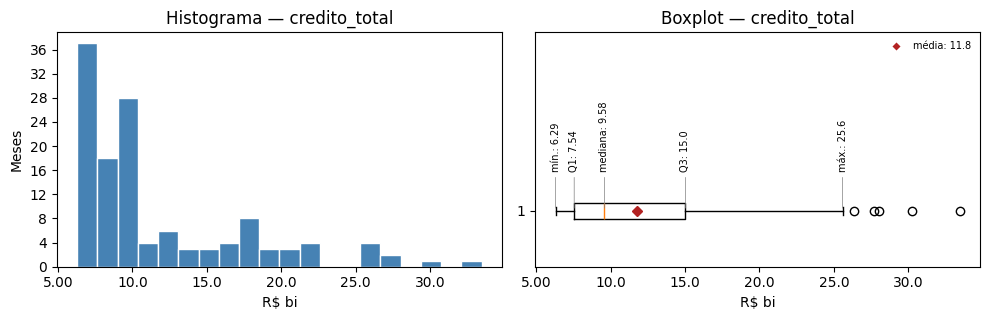

**credito_total** — Crédito total concedido pelos bancos de Santos: quanto maior, mais empréstimos e financiamentos estavam circulando na economia local naquele mês.

Ao longo dos 129 meses observados, o valor variou entre 6.29 (jul/2025) e 33.5 (jun/2016) R$ bi, com valor típico (mediana) de 9.58 R$ bi.

A distribuição é assimétrica à direita: a maioria dos meses tem valores mais baixos, mas alguns meses puxam bastante pra cima — por isso a média (11.8) fica acima da mediana (9.58).

O boxplot aponta 5 mês(es) fora do padrão típico da série (outliers), concentrados principalmente em 2016, 2018, 2019.

Nesses mesmos meses: **ativo_total** esteve alto (acima do Q3) em todos os 5 meses; **importação_kg** esteve baixo (abaixo do Q1) em 3 de 5 meses.

A tabela abaixo traz a linha completa do painel pra esses meses, com as células fora da faixa típica (Q1–Q3) de cada variável destacadas.

**Mesmo padrão de `ativo_total`:** o cruzamento visual com o câmbio nos meses de outlier é o mesmo, e a investigação formal — correlação de verdade, evolução ano a ano, hipótese do fechamento de agências — está no notebook `03_agencias_ativo_credito.ipynb`. Ver a nota completa na seção de `ativo_total`, acima.

,ano,mes,cambio_venda,ativo_total (R$ bi),credito_total (R$ bi),exportação_fob (US$ bi),importação_fob (US$ bi),exportação_kg (mi t),importação_kg (mi t)
17,2016,6,3.21,57.3,33.5,4.58,3.53,6.46,1.74
38,2018,3,3.32,86.3,26.4,6.34,4.18,9.31,1.98
50,2019,3,3.90,94.9,27.7,5.51,3.82,8.06,1.57
53,2019,6,3.83,94.9,28.0,4.94,4.12,7.42,1.95
54,2019,7,3.76,95.8,30.3,5.52,5.00,9.22,2.47


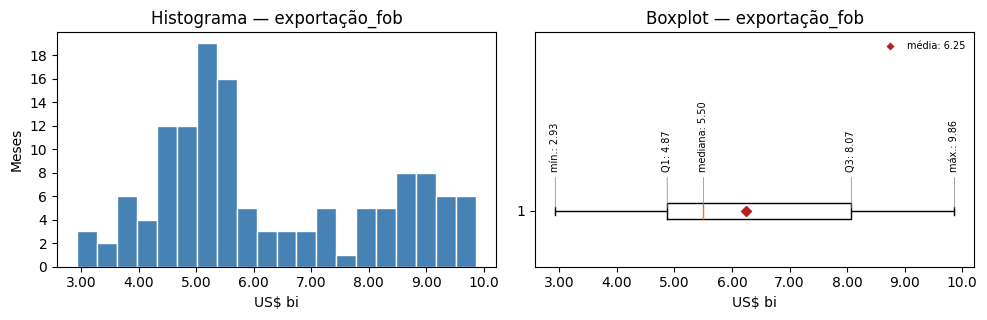

**exportação_fob** — Valor das exportações pelo Porto de Santos (em dólares, sem frete/seguro): mede o tamanho econômico de tudo que saiu do Brasil por ali naquele mês.

Ao longo dos 132 meses observados, o valor variou entre 2.93 (jan/2016) e 9.86 (mai/2025) US$ bi, com valor típico (mediana) de 5.50 US$ bi.

A distribuição é relativamente simétrica — média (6.25) e mediana (5.50) ficam próximas, sem uma cauda dominante de um lado só.

O boxplot não aponta nenhum mês fora do padrão típico (outliers) — o comportamento se manteve dentro de uma faixa relativamente previsível ao longo de todo o período.

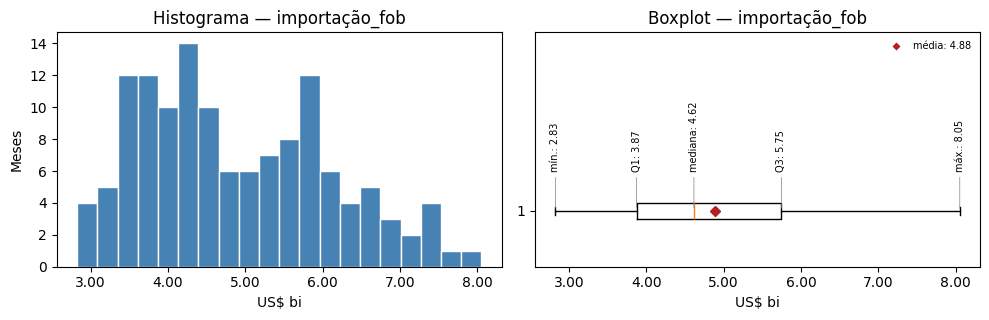

**importação_fob** — Valor das importações pelo Porto de Santos (em dólares, sem frete/seguro): mede o tamanho econômico de tudo que entrou no Brasil por ali naquele mês.

Ao longo dos 132 meses observados, o valor variou entre 2.83 (dez/2015) e 8.05 (ago/2022) US$ bi, com valor típico (mediana) de 4.62 US$ bi.

A distribuição é relativamente simétrica — média (4.88) e mediana (4.62) ficam próximas, sem uma cauda dominante de um lado só.

O boxplot não aponta nenhum mês fora do padrão típico (outliers) — o comportamento se manteve dentro de uma faixa relativamente previsível ao longo de todo o período.

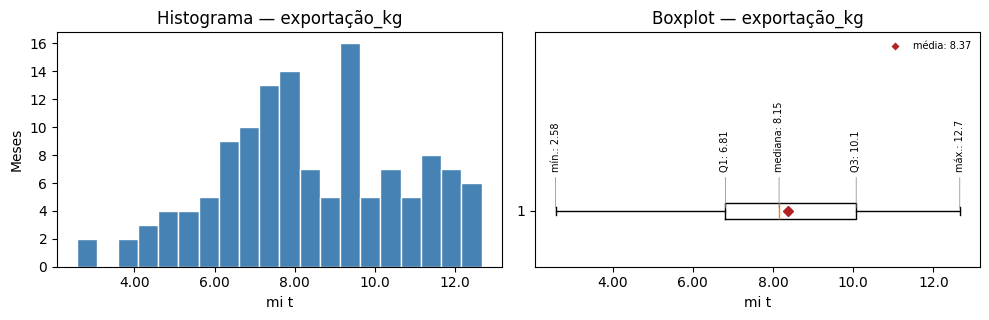

**exportação_kg** — Peso das exportações pelo Porto de Santos: mede o volume físico (não o valor em dinheiro) de carga que saiu do país por ali.

Ao longo dos 132 meses observados, o valor variou entre 2.58 (abr/2015) e 12.7 (mai/2025) mi t, com valor típico (mediana) de 8.15 mi t.

A distribuição é relativamente simétrica — média (8.37) e mediana (8.15) ficam próximas, sem uma cauda dominante de um lado só.

O boxplot não aponta nenhum mês fora do padrão típico (outliers) — o comportamento se manteve dentro de uma faixa relativamente previsível ao longo de todo o período.

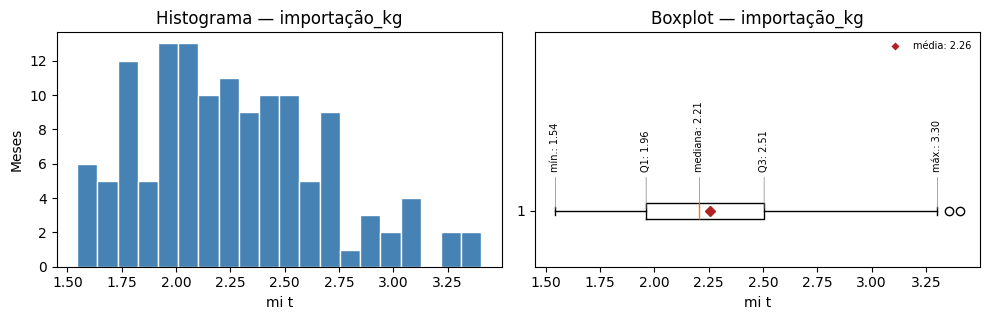

**importação_kg** — Peso das importações pelo Porto de Santos: mede o volume físico de carga que entrou no país por ali.

Ao longo dos 132 meses observados, o valor variou entre 1.54 (jan/2016) e 3.41 (set/2021) mi t, com valor típico (mediana) de 2.21 mi t.

A distribuição é assimétrica à direita: a maioria dos meses tem valores mais baixos, mas alguns meses puxam bastante pra cima — por isso a média (2.26) fica acima da mediana (2.21).

O boxplot aponta 2 mês(es) fora do padrão típico da série (outliers), concentrados principalmente em 2021.

Nesses mesmos meses: **cambio_venda** esteve alto (acima do Q3) em todos os 2 meses; **importação_fob** esteve alto (acima do Q3) em 1 de 2 meses; **exportação_kg** esteve baixo (abaixo do Q1) em 1 de 2 meses.

A tabela abaixo traz a linha completa do painel pra esses meses, com as células fora da faixa típica (Q1–Q3) de cada variável destacadas.

**Detalhamento por produto:** o notebook `02_outlier_importacao_2021.ipynb` abre esses dois meses por NCM (Comex Stat) pra investigar a causa — o câmbio estava alto nos dois, mas o volume bateu recorde da série mesmo assim. O resultado: 46% do peso importado veio só do capítulo de adubos e fertilizantes, e mais de 62% somando os insumos ligados a essa cadeia (enxofre, químicos inorgânicos) — carga pesada e barata por quilo, puxada pelo calendário da safra de verão 2021/22, não pela relação de preço/câmbio.

,ano,mes,cambio_venda,ativo_total (R$ bi),credito_total (R$ bi),exportação_fob (US$ bi),importação_fob (US$ bi),exportação_kg (mi t),importação_kg (mi t)
80,2021,9,5.44,41.6,7.66,6.34,5.97,7.16,3.41
81,2021,10,5.64,42.5,7.76,5.39,5.47,6.36,3.36


In [2]:
import matplotlib.ticker as mticker
from IPython.display import display, Markdown, HTML

# unidade de cada variável, pra rotular o eixo certo, e um contexto em
# linguagem simples sobre o que ela representa (usado no comentário de análise)
unidades = {
    'cambio_venda': None,           # já é uma taxa, não precisa de escala
    'ativo_total': 'R$',
    'credito_total': 'R$',
    'exportação_fob': 'US$',
    'importação_fob': 'US$',
    'exportação_kg': 'kg',
    'importação_kg': 'kg',
}

contexto = {
    'cambio_venda': "Câmbio (PTAX de venda): quanto mais alto, mais caro está o dólar em reais — um real mais fraco, o que tende a encarecer importações e favorecer exportadores.",
    'ativo_total': "Ativo total dos bancos com agência em Santos: soma de tudo que esses bancos possuem (principalmente os empréstimos que concederam). Funciona como um termômetro do tamanho do sistema bancário na praça de Santos, mês a mês.",
    'credito_total': "Crédito total concedido pelos bancos de Santos: quanto maior, mais empréstimos e financiamentos estavam circulando na economia local naquele mês.",
    'exportação_fob': "Valor das exportações pelo Porto de Santos (em dólares, sem frete/seguro): mede o tamanho econômico de tudo que saiu do Brasil por ali naquele mês.",
    'importação_fob': "Valor das importações pelo Porto de Santos (em dólares, sem frete/seguro): mede o tamanho econômico de tudo que entrou no Brasil por ali naquele mês.",
    'exportação_kg': "Peso das exportações pelo Porto de Santos: mede o volume físico (não o valor em dinheiro) de carga que saiu do país por ali.",
    'importação_kg': "Peso das importações pelo Porto de Santos: mede o volume físico de carga que entrou no país por ali.",
}

colunas = list(unidades.keys())
meses_nome = {1:'jan',2:'fev',3:'mar',4:'abr',5:'mai',6:'jun',
              7:'jul',8:'ago',9:'set',10:'out',11:'nov',12:'dez'}

def escala_e_sufixo(valor_max):
    if valor_max >= 1e9:
        return 1e9, 'bi'
    elif valor_max >= 1e6:
        return 1e6, 'mi'
    elif valor_max >= 1e3:
        return 1e3, 'mil'
    else:
        return 1, ''

def formata_valor(v):
    # ajusta a quantidade de casas decimais conforme a magnitude,
    # pra não mostrar "5.00" quando já é uma taxa nem "449.83621" numa escala grande
    if pd.isna(v):
        return ''
    if abs(v) < 10:
        return f'{v:.2f}'
    elif abs(v) < 100:
        return f'{v:.1f}'
    else:
        return f'{v:,.0f}'.replace(',', '.')

def prepara_dados_e_rotulo(col, dados):
    """Escala os dados pra uma unidade legível e devolve (dados_escalados, rótulo_do_eixo,
    unidade_pra_frase). unidade_pra_frase fica vazia quando a variável não tem unidade
    (ex.: cambio_venda), pra não colar o nome da coluna na frase de análise."""
    unidade = unidades[col]
    if unidade is None:
        return dados, col, ''
    if unidade == 'kg':
        # peso em comércio exterior costuma ser falado em toneladas, não em kg
        base = dados / 1000
        divisor, sufixo = escala_e_sufixo(base.max())
        rotulo = f'{sufixo} t'.strip() if sufixo else 't'
        return base / divisor, rotulo, rotulo
    divisor, sufixo = escala_e_sufixo(dados.max())
    rotulo = f'{unidade} {sufixo}'.strip()
    return dados / divisor, rotulo, rotulo

# visão geral das 7 variáveis já na mesma escala usada nos gráficos, e o Q1/Q3
# de cada uma ao longo de TODO o período — usados pra montar a tabela de
# contexto e classificar cada célula como "baixo"/"alto"/"típico" quando
# aparece um outlier em algum boxplot
dados_escalados, rotulos_gerais, quartis_gerais = {}, {}, {}
for c in colunas:
    dp, rot, _ = prepara_dados_e_rotulo(c, df[c].dropna())
    dados_escalados[c] = dp
    rotulos_gerais[c] = rot
    quartis_gerais[c] = (dp.quantile(0.25), dp.quantile(0.75))

nomes_colunas = {c: (f'{c} ({rotulos_gerais[c]})' if rotulos_gerais[c] != c else c) for c in colunas}
tabela_geral = df[['ano', 'mes']].join(pd.DataFrame(dados_escalados)).rename(columns=nomes_colunas)
mapa_nome_original = {v: k for k, v in nomes_colunas.items()}  # nome exibido -> nome original

def colorize_por_quartil(serie, col_ativo=None):
    """Pinta cada célula da coluna comparando com o Q1/Q3 dessa variável no
    período inteiro: abaixo do Q1 (baixo) em azul, acima do Q3 (alto) em laranja.
    A coluna que está sendo analisada no gráfico atual (col_ativo) recebe uma
    cor mais forte/saturada, pra bater o olho e ir direto nela; as demais
    colunas (o contexto ao redor) ficam num tom mais claro. A cor do texto é
    fixada (não herda do tema), pra continuar legível tanto no modo claro
    quanto no escuro do Jupyter."""
    if serie.name not in mapa_nome_original:
        return [''] * len(serie)
    col_original = mapa_nome_original[serie.name]
    q1, q3 = quartis_gerais[col_original]
    is_protagonista = col_original == col_ativo
    if is_protagonista:
        cor_baixo = 'background-color:#3d7fd6;color:#ffffff;font-weight:600'
        cor_alto = 'background-color:#ff9800;color:#ffffff;font-weight:600'
    else:
        cor_baixo = 'background-color:#e7f0ff;color:#4a6b96'
        cor_alto = 'background-color:#ffead0;color:#a66a2e'
    estilos = []
    for v in serie:
        if pd.isna(v):
            estilos.append('')
        elif v < q1:
            estilos.append(cor_baixo)
        elif v > q3:
            estilos.append(cor_alto)
        else:
            estilos.append('')
    return estilos

display(Markdown(
    "### Como ler os gráficos abaixo\n"
    "Pra cada variável do painel, mostramos dois gráficos lado a lado que se complementam:\n\n"
    "- **Histograma (esquerda):** conta em quantos dos meses observados o valor da variável "
    "caiu em cada faixa. Mostra o *formato* da distribuição — se os valores costumam ficar "
    "concentrados numa faixa só ou espalhados, se existe assimetria (uma cauda mais longa "
    "pra um lado), etc.\n"
    "- **Boxplot horizontal (direita):** resume a mesma variável em poucos números — o menor "
    "valor típico (mín.), o valor abaixo do qual estão 25% dos meses (Q1), o valor do meio "
    "(mediana), o valor abaixo do qual estão 75% dos meses (Q3), o maior valor típico (máx.) "
    "e a média (losango vermelho). Os círculos fora dessa faixa são meses **atípicos** — "
    "bem mais altos ou mais baixos do que o normal do período.\n\n"
    "Juntos, os dois respondem perguntas diferentes: o histograma mostra a *forma* da "
    "distribuição; o boxplot resume ela em poucos números e evidencia os meses fora do "
    "padrão. Quando existem meses atípicos, mostramos logo abaixo a linha completa do "
    "painel pra esses meses, já na mesma escala dos gráficos. Nessa tabela, cada célula é "
    "comparada com o **Q1 e o Q3 daquela variável ao longo de todo o período** (os mesmos "
    "números do boxplot dela): 🔵 **azul** = abaixo do Q1 (baixo pro padrão da variável), "
    "🟠 **laranja** = acima do Q3 (alto pro padrão da variável), sem cor = dentro da faixa "
    "típica (entre Q1 e Q3)."
))

for col in colunas:
    dados = df[col].dropna()
    dados_plot, rotulo_x, unidade_frase = prepara_dados_e_rotulo(col, dados)

    fig, axes = plt.subplots(1, 2, figsize=(10, 3.3))
    axes[0].hist(dados_plot, bins=20, color='steelblue', edgecolor='white')
    axes[0].set_title(f'Histograma — {col}')
    axes[0].set_xlabel(rotulo_x)
    axes[0].set_ylabel('Meses')
    # a contagem de meses é sempre inteira, então força ticks inteiros no eixo Y
    axes[0].yaxis.set_major_locator(mticker.MaxNLocator(integer=True))

    bp = axes[1].boxplot(
        dados_plot, vert=False, showmeans=True,
        meanprops=dict(marker='D', markerfacecolor='firebrick',
                        markeredgecolor='firebrick', markersize=5),
    )
    axes[1].set_title(f'Boxplot — {col}')
    axes[1].set_xlabel(rotulo_x)

    # extrai os valores direto dos elementos desenhados pelo boxplot
    # (garante que bate com o que está na figura, mesmo quando o
    # matplotlib recorta os bigodes por causa de outliers)
    box_x = bp['boxes'][0].get_xdata()
    q1, q3 = box_x.min(), box_x.max()
    mediana = bp['medians'][0].get_xdata()[0]
    media = bp['means'][0].get_xdata()[0]
    bigode_min = min(cap.get_xdata()[0] for cap in bp['caps'])
    bigode_max = max(cap.get_xdata()[0] for cap in bp['caps'])

    pontos = [
        (bigode_min, 'mín.'),
        (q1, 'Q1'),
        (mediana, 'mediana'),
        (q3, 'Q3'),
        (bigode_max, 'máx.'),
    ]
    for valor, rotulo in pontos:
        axes[1].annotate(
            f'{rotulo}: {formata_valor(valor)}',
            xy=(valor, 1), xytext=(valor, 1.35),
            ha='center', va='bottom', fontsize=7, rotation=90,
            arrowprops=dict(arrowstyle='-', lw=0.5, color='gray'),
        )
    axes[1].set_ylim(0.5, 2.6)  # abre espaço acima da caixa pros rótulos

    axes[1].legend(
        [plt.Line2D([0], [0], marker='D', color='w', markerfacecolor='firebrick', markersize=5)],
        [f'média: {formata_valor(media)}'], loc='upper right', fontsize=7, frameon=False,
    )

    # tick labels no mesmo formato usado nos rótulos (com separador de milhar pt-br)
    formatter = mticker.FuncFormatter(lambda x, pos: formata_valor(x))
    axes[0].xaxis.set_major_formatter(formatter)
    axes[1].xaxis.set_major_formatter(formatter)

    plt.tight_layout()
    plt.show()

    display(HTML("<div style='height:18px'></div>"))

    # --- comentário de análise, gerado a partir dos dados já na escala do gráfico ---
    q1_real, q3_real = dados_plot.quantile(0.25), dados_plot.quantile(0.75)
    iqr = q3_real - q1_real
    lo_fence, hi_fence = q1_real - 1.5 * iqr, q3_real + 1.5 * iqr
    outliers = dados_plot[(dados_plot < lo_fence) | (dados_plot > hi_fence)]
    skew = dados_plot.skew()
    idx_min, idx_max = dados.idxmin(), dados.idxmax()
    sufixo_frase = f' {unidade_frase}' if unidade_frase else ''

    texto = [f"**{col}** — {contexto[col]}"]
    texto.append(
        f"Ao longo dos {len(dados_plot)} meses observados, o valor variou entre "
        f"{formata_valor(dados_plot.min())} ({meses_nome[df.loc[idx_min, 'mes']]}/{df.loc[idx_min, 'ano']}) "
        f"e {formata_valor(dados_plot.max())} ({meses_nome[df.loc[idx_max, 'mes']]}/{df.loc[idx_max, 'ano']})"
        f"{sufixo_frase}, com valor típico (mediana) de {formata_valor(mediana)}{sufixo_frase}."
    )
    if skew > 0.5:
        texto.append(
            f"A distribuição é assimétrica à direita: a maioria dos meses tem valores mais baixos, "
            f"mas alguns meses puxam bastante pra cima — por isso a média ({formata_valor(media)}) "
            f"fica acima da mediana ({formata_valor(mediana)})."
        )
    elif skew < -0.5:
        texto.append(
            f"A distribuição é assimétrica à esquerda: a maioria dos meses tem valores mais altos, "
            f"mas alguns meses puxam bastante pra baixo — por isso a média ({formata_valor(media)}) "
            f"fica abaixo da mediana ({formata_valor(mediana)})."
        )
    else:
        texto.append(
            f"A distribuição é relativamente simétrica — média ({formata_valor(media)}) e mediana "
            f"({formata_valor(mediana)}) ficam próximas, sem uma cauda dominante de um lado só."
        )
    if len(outliers) > 0:
        anos_out = sorted(df.loc[dados_plot.index, 'ano'][outliers.index].unique().tolist())
        texto.append(
            f"O boxplot aponta {len(outliers)} mês(es) fora do padrão típico da série (outliers), "
            f"concentrados principalmente em {', '.join(str(a) for a in anos_out)}."
        )

        # -- padrão cruzado: nesses meses, quais outras variáveis também estavam
        # consistentemente altas ou baixas (maioria >= 50% dos meses)? --
        padroes = []
        for c in colunas:
            if c == col:
                continue
            q1c, q3c = quartis_gerais[c]
            vals = dados_escalados[c].reindex(outliers.index)
            n = vals.notna().sum()
            if n == 0:
                continue
            n_baixo = (vals < q1c).sum()
            n_alto = (vals > q3c).sum()
            if n_baixo / n >= 0.5:
                qualif = f"todos os {n} meses" if n_baixo == n else f"{n_baixo} de {n} meses"
                padroes.append(f"**{c}** esteve baixo (abaixo do Q1) em {qualif}")
            elif n_alto / n >= 0.5:
                qualif = f"todos os {n} meses" if n_alto == n else f"{n_alto} de {n} meses"
                padroes.append(f"**{c}** esteve alto (acima do Q3) em {qualif}")
        if padroes:
            texto.append("Nesses mesmos meses: " + "; ".join(padroes) + ".")
        texto.append("A tabela abaixo traz a linha completa do painel pra esses meses, com as células fora da faixa típica (Q1–Q3) de cada variável destacadas.")
        if col == 'importação_kg':
            texto.append(
                "**Detalhamento por produto:** o notebook `02_outlier_importacao_2021.ipynb` "
                "abre esses dois meses por NCM (Comex Stat) pra investigar a causa — o "
                "câmbio estava alto nos dois, mas o volume bateu recorde da série mesmo assim. "
                "O resultado: 46% do peso importado veio só do capítulo de adubos e fertilizantes, "
                "e mais de 62% somando os insumos ligados a essa cadeia (enxofre, químicos "
                "inorgânicos) — carga pesada e barata por quilo, puxada pelo calendário da safra "
                "de verão 2021/22, não pela relação de preço/câmbio."
            )
        elif col == 'ativo_total':
            texto.append(
                "**O que dá pra perceber só olhando a tabela acima:** nos meses em que "
                "`ativo_total` foge do padrão, outras variáveis também aparecem fora do seu "
                "próprio padrão nesses mesmos meses — é esse cruzamento visual (cores e valores "
                "lado a lado) que chama atenção entre `ativo_total`/`credito_total` e o câmbio. "
                "Mas aparecer junto numa tabela de outliers não é a mesma coisa que confirmar a "
                "relação: o notebook `03_agencias_ativo_credito.ipynb` formaliza isso — calcula a "
                "correlação de verdade, olha a evolução ano a ano, e testa se o fechamento de "
                "agências bancárias físicas em Santos (mesma fonte, ESTBAN) ajuda a explicar o "
                "padrão. Os notebooks 02 e 03 são extensões pontuais deste 01, nascidas de "
                "perguntas que surgiram olhando pros outliers; do notebook 04 em diante a gente "
                "retoma a sequência do roteiro (temporal → NaNs → correlação → estacionariedade → "
                "decomposição) mais à risca."
            )
        elif col == 'credito_total':
            texto.append(
                "**Mesmo padrão de `ativo_total`:** o cruzamento visual com o câmbio nos meses "
                "de outlier é o mesmo, e a investigação formal — correlação de verdade, evolução "
                "ano a ano, hipótese do fechamento de agências — está no notebook "
                "`03_agencias_ativo_credito.ipynb`. Ver a nota completa na seção de `ativo_total`, "
                "acima."
            )
    else:
        texto.append(
            "O boxplot não aponta nenhum mês fora do padrão típico (outliers) — o comportamento "
            "se manteve dentro de uma faixa relativamente previsível ao longo de todo o período."
        )
    display(Markdown('\n\n'.join(texto)))

    if len(outliers) > 0:
        display(HTML("<div style='height:14px'></div>"))
        linhas = tabela_geral.loc[outliers.index].sort_values(['ano', 'mes'])
        valor_cols = [c for c in linhas.columns if c not in ('ano', 'mes')]
        styler = (
            linhas.style
            .apply(colorize_por_quartil, axis=0, col_ativo=col)
            .format(formata_valor, subset=valor_cols)
        )
        display(styler)

    display(HTML("<hr style='margin:2.2em 0; border:none; border-top:1px solid #ddd;'>"))